In [4]:
!pip install optuna scikit-learn pandas matplotlib seaborn

  Obtaining dependency information for optuna from https://files.pythonhosted.org/packages/ac/24/7c731839566d30dc70556d9824ef17692d896c15e3df627bce8c16f753e1/optuna-4.8.0-py3-none-any.whl.metadata
  Obtaining dependency information for alembic>=1.5.0 from https://files.pythonhosted.org/packages/d2/29/6533c317b74f707ea28f8d633734dbda2119bbadfc61b2f3640ba835d0f7/alembic-1.18.4-py3-none-any.whl.metadata
  Obtaining dependency information for colorlog from https://files.pythonhosted.org/packages/6d/c1/e419ef3723a074172b68aaa89c9f3de486ed4c2399e2dbd8113a4fdcaf9e/colorlog-6.10.1-py3-none-any.whl.metadata
  Obtaining dependency information for sqlalchemy>=1.4.2 from https://files.pythonhosted.org/packages/f2/af/c3c7e1f3a2b383155a16454df62ae8c62a30dd238e42e68c24cebebbfae6/sqlalchemy-2.0.48-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for Mako from https://files.pythonhosted.org/packages/87/fb/99f81ac72ae23375f22b7afdb7642aba97c00a713c217124420147681a2f/mako-1.3.10-py3-


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("jobs-and-job-description/job_title_des.csv")  
# your Kaggle dataset

X = df['Job Description']
y = df['Job Title']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline pipeline
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))

Baseline Accuracy: 0.8092105263157895


In [2]:
import optuna
from sklearn.metrics import accuracy_score

def objective(trial):
    # Hyperparameters to tune
    max_features = trial.suggest_int("max_features", 500, 5000)
    ngram_range = trial.suggest_categorical("ngram_range", [(1,1), (1,2)])
    C = trial.suggest_float("C", 0.01, 10.0, log=True)

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range
        )),
        ("clf", LogisticRegression(C=C, max_iter=1000))
    ])

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return accuracy_score(y_test, preds)

# Create study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Parameters:", study.best_params)
print("Best Accuracy:", study.best_value)

c:\Users\nvgok\Downloads\task1_2.0\torch_cuda_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-26 13:05:02,163] A new study created in memory with name: no-name-5bfdf7b0-0ae0-4af8-af25-af260dcda078
c:\Users\nvgok\Downloads\task1_2.0\torch_cuda_env\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  optuna_warn(message)
c:\Users\nvgok\Downloads\task1_2.0\torch_cuda_env\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  optuna_warn(message)
[I 2026-03-26 13:05:04,141] Tri

Best Parameters: {'max_features': 2058, 'ngram_range': (1, 1), 'C': 5.373054491064724}
Best Accuracy: 0.8267543859649122


In [3]:
best_params = study.best_params

final_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=best_params["max_features"],
        ngram_range=best_params["ngram_range"]
    )),
    ("clf", LogisticRegression(
        C=best_params["C"],
        max_iter=1000
    ))
])

final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Optimized Accuracy: 0.8267543859649122
                        precision    recall  f1-score   support

     Backend Developer       0.58      0.47      0.52        32
Database Administrator       1.00      1.00      1.00        26
       DevOps Engineer       0.94      0.84      0.89        38
      Django Developer       0.85      0.79      0.82        29
     Flutter Developer       0.92      0.97      0.94        35
  Full Stack Developer       1.00      1.00      1.00        23
        Java Developer       0.71      0.76      0.73        38
  JavaScript Developer       0.74      0.79      0.77        39
      Machine Learning       0.92      0.82      0.87        28
 Network Administrator       0.81      0.94      0.87        18
     Node js developer       0.85      0.82      0.84        34
         PHP Developer       0.77      0.88      0.82        26
     Software Engineer       0.57      0.72      0.64        32
   Wordpress Developer       0.95      0.91      0.93        23


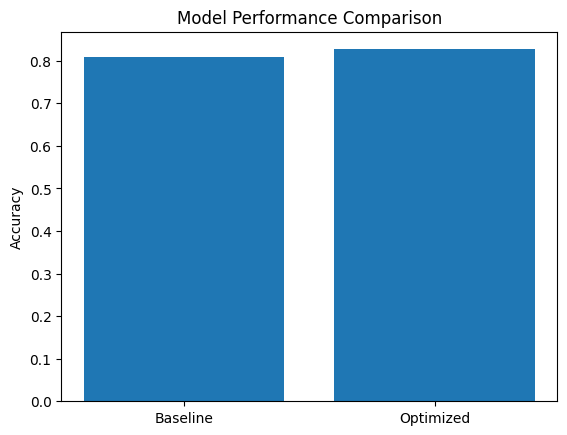

In [4]:
import matplotlib.pyplot as plt

baseline_acc = accuracy_score(y_test, baseline_model.predict(X_test))
optuna_acc = accuracy_score(y_test, y_pred_final)

plt.bar(["Baseline", "Optimized"], [baseline_acc, optuna_acc])
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.show()

In [9]:
!pip install plotly

  Obtaining dependency information for plotly from https://files.pythonhosted.org/packages/52/d2/c6e44dba74f17c6216ce1b56044a9b93a929f1c2d5bdaff892512b260f5e/plotly-6.6.0-py3-none-any.whl.metadata
  Obtaining dependency information for narwhals>=1.15.1 from https://files.pythonhosted.org/packages/3f/c3/06490e98393dcb4d6ce2bf331a39335375c300afaef526897881fbeae6ab/narwhals-2.18.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.9 MB 1.1 MB/s eta 0:00:10
    --------------------------------------- 0.2/9.9 MB 1.8 MB/s eta 0:00:06
   - -------------------------------------- 0.3/9.9 MB 2.0 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/9.9 MB 2.5 MB/s eta 0:00:04
   -- ------------------------------------- 0.7/9.9 MB 2.9 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.9 MB 2.8 MB/s eta 0:00:04


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!pip install nbformat

  Obtaining dependency information for nbformat from https://files.pythonhosted.org/packages/a9/82/0340caa499416c78e5d8f5f05947ae4bc3cba53c9f038ab6e9ed964e22f1/nbformat-5.10.4-py3-none-any.whl.metadata
  Obtaining dependency information for fastjsonschema>=2.15 from https://files.pythonhosted.org/packages/cb/a8/20d0723294217e47de6d9e2e40fd4a9d2f7c4b6ef974babd482a59743694/fastjsonschema-2.21.2-py3-none-any.whl.metadata
  Obtaining dependency information for jsonschema>=2.6 from https://files.pythonhosted.org/packages/69/90/f63fb5873511e014207a475e2bb4e8b2e570d655b00ac19a9a0ca0a385ee/jsonschema-4.26.0-py3-none-any.whl.metadata
  Obtaining dependency information for jsonschema-specifications>=2023.03.6 from https://files.pythonhosted.org/packages/41/45/1a4ed80516f02155c51f51e8cedb3c1902296743db0bbc66608a0db2814f/jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata
  Obtaining dependency information for referencing>=0.28.4 from https://files.pythonhosted.org/packages/2c/58/ca301544


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import optuna.visualization as vis

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()